# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [6]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ----

## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [13]:
from assertpy import assert_that
from tqdm import tqdm
from nltk.util import ngrams

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded = [start_symbol] * (n-1) + list(text) + [end_symbol] *  n
    n_grams = list()
    for i in range(0, len(padded) - n + 1):
        n_grams.append(''.join(padded[i:i+n]))
    
    return n_grams

    

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [16]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    i = 0
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
            n2i[ngram] = i
            i2n.append(count)
            i += 1    
        else:
            n_rare += 1            
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<?, ?it/s]


Building mapping...


100%|██████████| 15/15 [00:00<?, ?it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [17]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram) if ngram in n2i_mapping else unknown_idx
            
            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for i in prev_indices[-window_size:]:
                co_matrix[idx, i] += 1
                co_matrix[i, idx] +=1
             
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        co_matrix[i, j] /= row_sums[i]

    
    return co_matrix

In [18]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 43903.99it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2815990.22it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [07:17<00:00, 83.10it/s] 


Normalizing...


100%|██████████| 2542234/2542234 [00:54<00:00, 46436.93it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [37]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [21]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        if len(url) < padded_len:
            url = url + (padded_len - len(url)) * pad_symbol
        
        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i,j] = n2i_mapping.get(ngram, unknown_idx)
    
    return batch

In [22]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [60]:
import torch.nn.functional as F
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        embedding_weights = torch.tensor(embedding_weights, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(embedding_weights, freeze=True)

        
        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(in_channels= 20, out_channels=40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(in_channels=40, out_channels=80, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.pool2 = nn.MaxPool1d(kernel_size=5)
        self.pool3 = nn.MaxPool1d(kernel_size=5)
        
        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(in_features=160, out_features=16)
        self.fc2 = nn.Linear(in_features=16, out_features=1)

        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = torch.flatten(x, start_dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x))
        return x

In [61]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [72]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        y_pred = model(x).squeeze(1)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += ((y_pred > 0.5) == y).sum().item()
        total += len(y)
        
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x).squeeze(1)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [73]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.8973, Val Acc=0.9032
Epoch 2: Train Acc=0.9080, Val Acc=0.9161
Epoch 3: Train Acc=0.9141, Val Acc=0.9229
Epoch 4: Train Acc=0.9206, Val Acc=0.9144
Epoch 5: Train Acc=0.9245, Val Acc=0.9206
Epoch 6: Train Acc=0.9283, Val Acc=0.9290
Epoch 7: Train Acc=0.9308, Val Acc=0.9353
Epoch 8: Train Acc=0.9326, Val Acc=0.9339
Epoch 9: Train Acc=0.9350, Val Acc=0.9301
Epoch 10: Train Acc=0.9366, Val Acc=0.9378


## 6. Evaluation

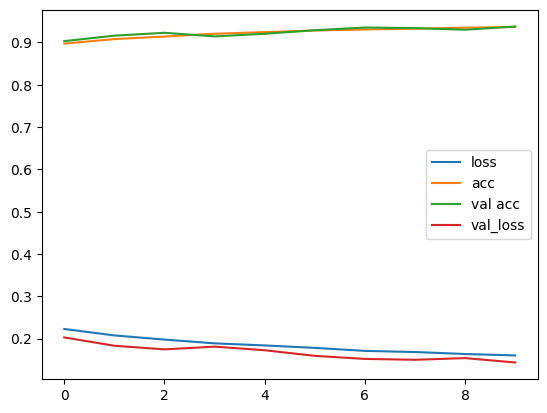

In [74]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
x = np.arange(0, N_EPOCHS)
plt.plot(x, history['loss'], label = 'loss')
plt.plot(x, history['acc'], label = 'acc')
plt.plot(x, history['val_acc'], label = 'val acc')
plt.plot(x, history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

In [78]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x).squeeze(1)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
            y_true.extend(y.cpu().numpy())
            y_pred.extend((out > 0.5).int().cpu().numpy())
    return total_loss / total, correct / total, y_true, y_pred, 



test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
print(f"loss: {test_loss}")
print(f"acc: {test_acc}")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

loss: 0.1559598654348628
acc: 0.9333608587943848
[[6642  501]
 [ 306 4661]]
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      7143
         1.0       0.90      0.94      0.92      4967

    accuracy                           0.93     12110
   macro avg       0.93      0.93      0.93     12110
weighted avg       0.93      0.93      0.93     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:** Yes, we can see based on the graph of loss and accuracy over time, we can see that both accuracy and loss exhibit an inverse relationship, as loss lowers we get a higher accuracy. At the end, they start to plateau. 



**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:** Using a large window size allows you to look further back in memory, which can help detect more patterns. Other compression methods may include finding commonly occuring patterns and compressing them to something shorter, with recovery being using a dict look up table. 



## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`